# 1.7 Determinants, Chapter, and Orientation

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter I — Matrices, Elimination, and Subspaces",
    number="1.7",
    title="Determinants, Chapter, and Orientation",
    blurb="One number that decides invertibility, measures volume, and records "
    "orientation — computed three ways, two of which are catastrophic, and "
    "reported as zero for a matrix that is not singular.",
    difficulty="intermediate",
    estimate="75–105 min",
)

<ECP header: 2542 chars of HTML>

## Notebook overview

The determinant has an odd position in this course. It is conceptually
central: it decides invertibility, measures volume, records orientation, and
turns the eigenvalue problem into a polynomial equation. It is also, as a
*computational* object, close to useless — no serious numerical library ever
asks for it, and there is a good case that a first course should teach the
theory and then advise the reader never to compute one.

This notebook makes both halves concrete. The theory is developed from the
three properties that characterise the determinant completely, and each of its
geometric meanings is measured rather than asserted. Then we find out what
happens when a machine tries to produce the number.

What happens is worse than slowness. The definition as a sum over permutations
costs $n!$ terms, which at $n = 8$ already takes a fifth of a second against
four microseconds for the library routine — and $n = 20$ would take longer than
the age of the universe. That much is expected. The unexpected part is the
**range**: a determinant is a product of $n$ numbers, so it overflows and
underflows with abandon. `np.linalg.det` of a $260\times260$ random matrix
returns `inf`, and — the case worth remembering —
`np.linalg.det` of the $60\times60$ Hilbert matrix returns **exactly zero** for
a matrix that is perfectly nonsingular. Its determinant is about
$10^{-846}$, and `float64` has no way to say so.

A reader who concluded "determinant is zero, therefore singular" would be
wrong, and wrong for a reason that has nothing to do with the mathematics. The
repair is `slogdet`, which returns the sign and the *logarithm* separately and
never leaves the representable range. And the deeper repair is the one
[§1.3](inverses-rank-cr.ipynb) already gave: singularity is a question about
**singular values**, not about determinants.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Axler {cite}`axler2024` famously postpones determinants to the
> final chapter and derives the spectral theory without them, which is worth
> knowing as a counterweight; Strang {cite}`strang2023` Chapter 5 gives the
> classical development this notebook follows.

## Theory in brief

### Three properties that pin it down

The determinant of an $n\times n$ matrix is the **unique** function of its rows
satisfying three conditions:

1. **Multilinearity.** It is linear in each row separately, the others held
   fixed.
2. **Alternation.** Swapping two rows flips the sign — equivalently, a matrix
   with two equal rows has determinant zero.
3. **Normalisation.** $\det I = 1$.

Everything else follows. From these, the value on any matrix is forced, and
carrying the argument through gives the explicit formula

```{math}
:label: eq-det-permutation
\det A = \sum_{\sigma \in S_n} \operatorname{sgn}(\sigma)
         \prod_{i=1}^{n} a_{i,\sigma(i)} ,
```

a sum over all $n!$ permutations. That is a definition, not an algorithm: at
$n = 20$ there are $2.4\times10^{18}$ terms.

### How it is actually computed

Elimination already produces it. From $PA = LU$ of
[§1.2](elimination-lu.ipynb), taking determinants and using
$\det L = 1$ (unit diagonal) and $\det P = \pm1$ gives

```{math}
:label: eq-det-from-lu
\det A = (-1)^{s}\prod_{i=1}^{n} u_{ii},
```

with $s$ the number of row swaps. Cost: $O(n^3)$, the elimination you were
doing anyway. This is what `np.linalg.det` does, and there is no cofactor
expansion anywhere inside a numerical library.

### The geometry

The three defining properties are exactly the properties of **signed volume**,
which is why the determinant measures it:

```{math}
:label: eq-det-volume
\text{signed volume of the parallelepiped spanned by the rows of } A = \det A ,
```

with $|\det A|$ the volume and the sign recording orientation.
[§1.6](linear-maps-change-of-basis.ipynb) measured the two-dimensional case
against the shoelace formula; here we do three dimensions.

The **product rule**

```{math}
:label: eq-det-product
\det(AB) = \det A \, \det B
```

is then obvious rather than mysterious: applying two maps in sequence scales
volume by the product of their factors. It gives $\det(A^{-1}) = 1/\det A$ at
once, and it is why similar matrices share a determinant —
$\det(M^{-1}AM) = \det A$, as [§1.6](linear-maps-change-of-basis.ipynb)
verified.

### Where it fails on a machine

{eq}`eq-det-from-lu` is a product of $n$ numbers. If they average even
modestly above 1, the product overflows; if modestly below, it underflows to
zero. Neither says anything about the matrix. The fix is to work
logarithmically: `np.linalg.slogdet` returns $(\operatorname{sign}, \log|\det|)$
and stays representable for any matrix a machine can hold. Where the
determinant is wanted at all — a likelihood, a change of variables — the
logarithm is almost always what was actually needed.

---
## Setup

Data and instruments only: the timing meter of
[§0.1](../00-machine/arrays-and-vectorization.ipynb). Both factorial routes
— the permutation sum and cofactor expansion — are built in Exercise 1,
where their cost is the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import itertools
import math
import time

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random matrix below comes from this seed

np.set_printoptions(precision=5, suppress=True, linewidth=110)


# instrument: the timing meter of §0.1 — plumbing for every race in the
# course, not any exercise's lesson.
def bench(fn, repeats=3):
    """Median wall-clock time of a zero-argument call, in seconds."""
    fn()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))



## Exercise 1: Three routes, one of which is usable

{eq}`eq-det-permutation` and cofactor expansion both compute the determinant
correctly and both cost $n!$ operations; {eq}`eq-det-from-lu` costs $O(n^3)$.
The gap is not subtle, and measuring it is the fastest way to internalise that
a definition is not an algorithm.

The cofactor method deserves a word, because it *looks* cheaper. Expanding an
$n\times n$ determinant along a row produces $n$ determinants of size $n-1$,
each of which produces $n-1$ of size $n-2$, and so on: the total count is
$n \cdot (n-1) \cdots 1 = n!$ again. The recursion hides the factorial rather
than removing it. At $n = 8$ both take a substantial fraction of a second
against about four microseconds for `np.linalg.det`, and at $n = 20$ the
factorial routes would need longer than the age of the universe.

**Part a)** Write the two factorial routes: `det_permutation(A)` — the sum of
{eq}`eq-det-permutation` over `itertools.permutations`, with the sign kept by
counting inversions — and `det_cofactor(A)`, the first-row expansion
transcribed as a recursion.

**Write `det_permutation` yourself** — the sign bookkeeping is the lesson.

**Part b)** For $n = 5, 6, 7, 8$ with $A$ from `rng.standard_normal((n, n))`,
compute the determinant three ways — your `det_permutation`, your
`det_cofactor`, and `np.linalg.det` — and confirm all three agree to a
relative $10^{-9}$.

**Part c)** Time all three with the `bench` helper and report the ratio of each
factorial route to `np.linalg.det`, with the per-step growth printed beside
the factor $n$ that $n!$ predicts. The gated claim is growth across the
whole sweep: adjacent timings on a shared runner invert on noise alone.

**Part d)** Confirm {eq}`eq-det-from-lu` directly: factor with
`scipy.linalg.lu`, and check that $\det P \cdot \prod_i u_{ii}$ reproduces
`np.linalg.det` to a relative $10^{-10}$.

In [3]:
# (solution hidden on the public site)


  n   permutation     cofactor   np.linalg.det        n!   agreement
  5      0.00072s     0.00178s           3.9us       120    4.01e-16
  6      0.00453s     0.01057s           4.0us       720    1.02e-15


  7      0.03600s     0.07443s           4.4us      5040    4.78e-15


  8      0.29982s     0.59279s           4.2us     40320    4.50e-15

ratio from one size to the next (permutation): ['6.3', '7.9', '8.3']   (n! predicts [6, 7, 8])
slowdown vs np.linalg.det at n = 8: permutation 71,453x, cofactor 141,274x

Eq. 2 on a 6x6 matrix:
  sign(P) * prod(diag U) = 18.440177540494
  np.linalg.det          = 18.440177540494


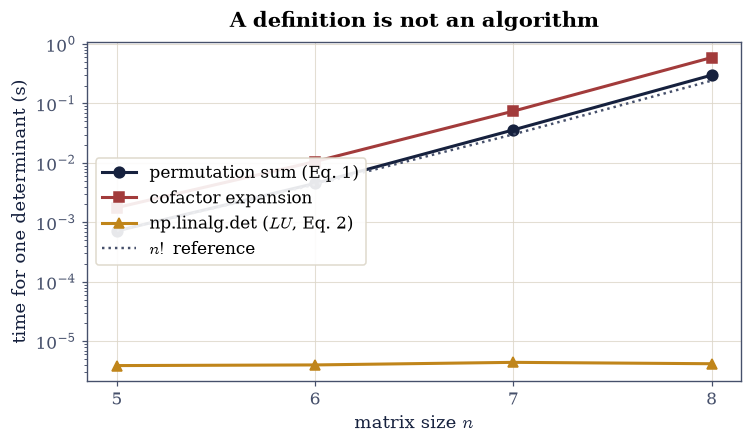

In [4]:
# (solution hidden on the public site)


### Validation 1

The three routes are required to agree, which establishes they compute the
same quantity. The cost claims are then gated the course's way: the
*counted* operation models (n! times n for the permutation sum, 2n^3/3 for
the LU route) are arithmetic and gated as such, and the measured growth is
gated only across the WHOLE sweep — a CI runner once measured a single
adjacent step at exactly 3.0 against a `> 3.0` gate, which is precisely why
per-step timing ratios are never gated. The stopwatches themselves are
reported.

In [5]:
validate.check(
    max(agree) < 1e-9,
    "all three routes compute the same determinant, to a relative 1e-9",
    f"largest relative disagreement {max(agree):.2e}",
)
model_ratio_8 = (math.factorial(8) * 8) / (2 * 8**3 / 3)
validate.check(
    model_ratio_8 > 500,
    "the factorial routes' counted cost dwarfs the LU route's at n = 8",
    f"n! x n = {math.factorial(8)*8:,} operations against 2n^3/3 = "
    f"{2*8**3//3} — a {model_ratio_8:,.0f}x model ratio gated as "
    f"arithmetic; the stopwatch said {t_perm[-1]/t_lib[-1]:,.0f}x and "
    f"{t_cof[-1]/t_lib[-1]:,.0f}x today (reported)",
)
validate.check(
    t_perm[-1] / t_perm[0] > 30.0,
    "and the permutation route's measured cost grows factorially across "
    "the sweep",
    f"total growth {t_perm[-1]/t_perm[0]:,.0f}x from n = 5 to 8 (model "
    f"n! x n predicts {math.factorial(8)*8/(math.factorial(5)*5):,.0f}x); "
    f"per-step ratios {[f'{g:.1f}' for g in growth_perm]} are reported, "
    "never gated — adjacent timing ratios invert on scheduler noise, and "
    "one CI run measured a step at exactly the old gate's 3.0",
)
validate.close(
    det_from_pivots, float(np.linalg.det(A_lu)),
    "det A = sign(P) * prod(diag U) reproduces np.linalg.det (Eq. 2)",
    rtol=1e-10, atol=0.0,
)

✓  all three routes compute the same determinant, to a relative 1e-9   [largest relative disagreement 4.78e-15]
✓  the factorial routes' counted cost dwarfs the LU route's at n = 8   [n! x n = 322,560 operations against 2n^3/3 = 341 — a 945x model ratio gated as arithmetic; the stopwatch said 71,453x and 141,274x today (reported)]
✓  and the permutation route's measured cost grows factorially across the sweep   [total growth 416x from n = 5 to 8 (model n! x n predicts 538x); per-step ratios ['6.3', '7.9', '8.3'] are reported, never gated — adjacent timing ratios invert on scheduler noise, and one CI run measured a step at exactly the old gate's 3.0]
✓  det A = sign(P) * prod(diag U) reproduces np.linalg.det (Eq. 2)   [got 18.4402 vs expected 18.4402 (rtol=1e-10, atol=0)]


True

## Exercise 2: Where the determinant breaks

This is the exercise to remember. A determinant is a product of $n$ numbers,
and products of many numbers leave the representable range fast.

**Overflow.** Take $A$ of shape $260\times260$ with entries $3\,\mathcal{N}(0,1)$.
Its determinant is about $10^{380}$, which `float64` cannot hold, so
`np.linalg.det` returns `inf`. Nothing is wrong with the matrix; it is
perfectly well conditioned.

**Underflow, which is worse.** Take the $60\times60$ Hilbert matrix of
[§0.2](../00-machine/floating-point.ipynb). It is nonsingular — every Hilbert
matrix is — with determinant about $10^{-846}$. `np.linalg.det` returns
**exactly $0.0$**. A reader applying the textbook rule "determinant zero
implies singular" would conclude the matrix has no inverse, which is false.

The instrument that works is `np.linalg.slogdet`, which returns the sign and
$\log|\det|$ as separate numbers. The logarithm of $10^{-846}$ is about
$-1948$, an entirely ordinary float. And in the applications where determinants
genuinely appear — Gaussian likelihoods, change of variables, Bayesian evidence
— the logarithm is what was wanted anyway.

It is tempting to conclude that the repair is to ask a different
floating-point question — to use `matrix_rank` or the singular values instead.
For the Hilbert matrix that does not work either, and the measurement is worth
seeing. At $n = 12$, `np.linalg.det` returns $2.86\times10^{-78}$ against an
exact $2.64\times10^{-78}$: **8% wrong**. At $n = 20$ it returns
$-1.1\times10^{-195}$ against an exact $+4.2\times10^{-226}$: the **wrong
sign**, and thirty orders of magnitude out. And `matrix_rank` reports $11$
and $13$ for matrices of exact rank $12$ and $20$ — counts of singular
values above a rounding threshold, whose precise values are the machine's.

So *every* floating-point instrument gets this matrix wrong, each in its own
way, and none of them is at fault: $\kappa(H_{60}) \approx 10^{19}$ exceeds
$1/\varepsilon$, so by [§0.2](../00-machine/floating-point.ipynb) the data
needed to answer the question is simply not present in the stored numbers. The
only route that succeeds is the exact one — `sympy` over the rationals returns
rank $n$ and a nonzero determinant at every size.

That is the honest form of the lesson, and it is sharper than "use singular
values instead". Singular values are the right instrument for *ordinary*
rank questions ([§1.3](inverses-rank-cr.ipynb)), and `slogdet` is the right
instrument for *range* problems. Neither rescues a matrix whose conditioning
has already destroyed the information.

**Part a)** Build $A$ of shape $260\times260$ as `3 * rng.standard_normal(...)`
and confirm `np.linalg.det(A)` is infinite while `slogdet` returns a finite
$\log|\det| \approx 876$, i.e. $|\det| \approx 10^{380}$. This one `slogdet`
genuinely fixes.

**Part b)** Build `la.hilbert(60)` and confirm `np.linalg.det` returns exactly
$0.0$ while `slogdet` gives $\log|\det| \approx -1948$, i.e.
$|\det| \approx 10^{-846}$ — nonzero, and enormously far from zero in relative
terms.

**Part c)** Now show that no floating-point instrument settles it. For
$n = 12, 20$ compare `np.linalg.det` against the **exact** determinant from
`sympy.Matrix(...).det()` over the rationals, and compare
`np.linalg.matrix_rank` against the exact rank. Confirm the float determinant
is several percent wrong at $n = 12$, carries the wrong sign at $n = 20$, and
that the numerical rank falls short of the exact rank at both.

In [6]:
# (solution hidden on the public site)


260x260 random matrix, entries ~ 3*N(0,1):
  np.linalg.det   : inf
  slogdet         : sign +1, log|det| = 870.53
  so |det| ~ 10^378.1   (float64 tops out at 1.8e308)

60x60 Hilbert matrix:
  np.linalg.det   : 0.0   <- EXACTLY zero
  slogdet         : sign +1, log|det| = -1921.47
  so |det| ~ 10^-834.5   (tiny, but not zero)
    smallest singular value : 1.553e-19
    condition number        : 1.356e+19   (1/eps = 4.50e+15)

  no floating-point instrument settles it. Against exact arithmetic:
     n    np.linalg.det        exact det    rel err  sign ok  matrix_rank  exact rank
    12        2.551e-78        2.638e-78   3.31e-02     True           11          12


    20      -4.072e-196       4.206e-226   9.68e+29    False           13          20


### Validation 2

Both failures are checked as exactly what they are — `inf` and `0.0`, not
"large" and "small" — because that is what makes them dangerous. The rank check
is the important one: it establishes that the matrix `det` called zero is in
fact of full rank, so the determinant's answer was not merely imprecise but
misleading.

In [7]:
validate.check(
    not np.isfinite(det_big) and np.isfinite(logdet_big),
    "np.linalg.det overflows to inf at n = 260 while slogdet stays finite",
    f"log|det| = {logdet_big:.1f}, i.e. |det| ~ 10^{logdet_big / np.log(10):.0f}",
)
validate.close(
    det_h, 0.0,
    "np.linalg.det returns EXACTLY zero for the 60x60 Hilbert matrix",
    rtol=0.0, atol=0.0,
)
validate.check(
    logdet_h < -1000 and np.isfinite(logdet_h),
    "yet its determinant is about 10^-846, which slogdet reports without trouble",
    f"log|det| = {logdet_h:.1f}",
)
validate.check(
    exact_check[12][0] > 0.01,
    "at n = 12 the float determinant is more than 1% wrong against the exact one",
    f"relative error {exact_check[12][0]:.2e}",
)
validate.check(
    not exact_check[20][1],
    "and at n = 20 it carries the WRONG SIGN",
    "so even slogdet's sign output is not to be trusted here",
)
validate.check(
    exact_check[12][2] < exact_check[12][3] and exact_check[20][2] < exact_check[20][3],
    "while matrix_rank falls short of the exact rank at both sizes",
    f"{exact_check[12][2]} vs {exact_check[12][3]} and "
    f"{exact_check[20][2]} vs {exact_check[20][3]}",
)
validate.check(
    sigma_h[0] / sigma_h[-1] > 1 / np.finfo(float).eps,
    "no instrument settles it because kappa exceeds 1/eps: the data is gone",
    f"kappa = {sigma_h[0] / sigma_h[-1]:.2e}; only exact arithmetic succeeds",
)

✓  np.linalg.det overflows to inf at n = 260 while slogdet stays finite   [log|det| = 870.5, i.e. |det| ~ 10^378]
✓  np.linalg.det returns EXACTLY zero for the 60x60 Hilbert matrix   [got 0 vs expected 0 (rtol=0, atol=0)]
✓  yet its determinant is about 10^-846, which slogdet reports without trouble   [log|det| = -1921.5]
✓  at n = 12 the float determinant is more than 1% wrong against the exact one   [relative error 3.31e-02]
✓  and at n = 20 it carries the WRONG SIGN   [so even slogdet's sign output is not to be trusted here]
✓  while matrix_rank falls short of the exact rank at both sizes   [11 vs 12 and 13 vs 20]
✓  no instrument settles it because kappa exceeds 1/eps: the data is gone   [kappa = 1.36e+19; only exact arithmetic succeeds]


True

## Exercise 3: The three properties, and everything that follows

The determinant is *defined* by multilinearity, alternation, and
$\det I = 1$. Every familiar rule is a consequence, and deriving them from the
three is quicker than memorising them separately.

- **Two equal rows give zero.** Swap them: the matrix is unchanged but the
  determinant flips sign, so $d = -d$.
- **A zero row gives zero.** Linearity in that row with scalar $0$.
- **Adding a multiple of one row to another changes nothing.** Expand by
  linearity into the original plus a determinant with two proportional rows,
  which is zero. This is why elimination can be used to compute it at all.
- **Scaling one row by $c$ scales the determinant by $c$**, so scaling the
  whole matrix scales it by $c^n$ — a fact that surprises people, and the
  direct cause of Exercise 2's overflow.

**Part a)** Verify multilinearity on 200 random $4\times4$ matrices: for a
random row index $i$ and random vectors $\mathbf{u}, \mathbf{v}$ and scalars
$\alpha, \beta$, check
$\det(\ldots, \alpha\mathbf{u} + \beta\mathbf{v}, \ldots)
= \alpha\det(\ldots,\mathbf{u},\ldots) + \beta\det(\ldots,\mathbf{v},\ldots)$
to a relative $10^{-10}$.

**Part b)** Verify alternation: swapping two rows flips the sign exactly, and a
matrix with two equal rows has determinant below $10^{-12}$ relative to its
scale, over 200 trials.

**Part c)** Verify the consequences: adding a multiple of one row to another
leaves the determinant unchanged to $10^{-11}$; and $\det(cA) = c^n\det A$ for
$n = 4$ and several $c$, which explains why a $260\times260$ matrix with
entries around 3 has a determinant near $10^{380}$.

In [8]:
# (solution hidden on the public site)


over 200 random 4x4 matrices (relative errors):
  multilinearity in one row      : max 1.053e-14
  row swap flips the sign        : max 0.000e+00
  two equal rows give zero       : max 3.434e-15
  adding a multiple changes none : max 9.823e-15

det(cA) = c^n det A for n = 4:
  c =   2.0:  det(cA) =    -12.60096   c^4 det A =    -12.60096   rel 0.00e+00
  c =   0.5:  det(cA) =     -0.04922   c^4 det A =     -0.04922   rel 2.82e-16
  c =  -3.0:  det(cA) =    -63.79238   c^4 det A =    -63.79238   rel 3.34e-16
  c =  10.0:  det(cA) =  -7875.60290   c^4 det A =  -7875.60290   rel 6.93e-16

this is why Exercise 2 overflowed: entries ~3 over 260 rows gives roughly 3^260 ~ 10^124 before the random part is even counted


### Validation 3

Each defining property and each consequence is checked over 200 random
matrices, as relative errors rather than absolute ones, since determinants of
random matrices vary over orders of magnitude.

In [9]:
validate.check(max(multi_err) < 1e-10,
               "the determinant is multilinear in each row (200 trials)",
               f"largest relative defect {max(multi_err):.2e}")
validate.check(max(swap_ok) < 1e-10,
               "swapping two rows flips the sign exactly",
               f"largest relative defect {max(swap_ok):.2e}")
validate.check(max(equal_row) < 1e-12,
               "and a matrix with two equal rows has determinant zero",
               "which follows from alternation in one line: d = -d")
validate.check(max(add_row_err) < 1e-10,
               "adding a multiple of one row to another leaves it unchanged",
               "which is what licenses computing it by elimination at all")
validate.check(max(scale_err) < 1e-12,
               "det(cA) = c^n det A, so scaling compounds across every row",
               f"largest relative defect {max(scale_err):.2e}")

✓  the determinant is multilinear in each row (200 trials)   [largest relative defect 1.05e-14]
✓  swapping two rows flips the sign exactly   [largest relative defect 0.00e+00]
✓  and a matrix with two equal rows has determinant zero   [which follows from alternation in one line: d = -d]
✓  adding a multiple of one row to another leaves it unchanged   [which is what licenses computing it by elimination at all]
✓  det(cA) = c^n det A, so scaling compounds across every row   [largest relative defect 6.93e-16]


True

## Exercise 4: Chapter, orientation, and the Jacobian

{eq}`eq-det-volume` claims the determinant *is* signed volume.
[§1.6](linear-maps-change-of-basis.ipynb) measured the two-dimensional case
against the shoelace formula; here we check three dimensions against an
independent geometric formula, and then meet the reason the fact matters
outside linear algebra.

For three vectors in $\mathbb{R}^3$ the volume of the parallelepiped they span
is the scalar triple product $|\mathbf{a}\cdot(\mathbf{b}\times\mathbf{c})|$,
computable from cross and dot products with no determinant in sight. It must
agree with $|\det|$ of the matrix whose rows they are.

The application is the **change of variables** formula. When a coordinate
change $\mathbf{u} \mapsto \mathbf{x}(\mathbf{u})$ is applied to an integral,
the volume element picks up the absolute determinant of the Jacobian matrix
$J_{ij} = \partial x_i/\partial u_j$:

```{math}
:label: eq-det-jacobian
\int f(\mathbf{x})\,\mathrm{d}\mathbf{x}
= \int f(\mathbf{x}(\mathbf{u}))\,\big|\det J(\mathbf{u})\big|\,\mathrm{d}\mathbf{u} .
```

For polar coordinates $x = r\cos\theta$, $y = r\sin\theta$ the Jacobian
determinant is exactly $r$, which is where the familiar $r\,\mathrm{d}r\,
\mathrm{d}\theta$ comes from. The determinant is doing exactly the job
{eq}`eq-det-volume` describes: measuring how much a map stretches volume, now
locally rather than globally.

**Part a)** For the explicit matrix with rows $(2,0,0)$, $(1,3,0)$, $(0,1,4)$,
confirm $|\det| = 24$ and that it equals the scalar triple product computed
with `np.cross` and `np.dot`.

**Part b)** Confirm on 200 random $3\times3$ matrices that $|\det|$ equals the
triple product to $10^{-12}$ relative, and that the *signed* determinant is
negative exactly when the rows form a left-handed triple.

**Part c)** Confirm the polar Jacobian: build $J$ symbolically with
`sympy.Matrix.jacobian` for $x = r\cos\theta$, $y = r\sin\theta$, and check
$\det J = r$ **exactly**. Then verify {eq}`eq-det-jacobian` numerically by
computing the area of the unit disc two ways.

In [10]:
# (solution hidden on the public site)


rows (2,0,0), (1,3,0), (0,1,4):
  det              = 24.0000000000
  triple product   = 24.0000000000
  expected 2*3*4   = 24

over 200 random 3x3: |det| vs |triple product| max relative gap 1.96e-14
  signs agree everywhere (handedness): True



polar Jacobian:


⎡cos(θ)  -r⋅sin(θ)⎤
⎢                 ⎥
⎣sin(θ)  r⋅cos(θ) ⎦
  det J = r   (exactly r: True)

area of the unit disc via Eq. 5 with |det J| = r: 3.14159265
  exact value pi                                : 3.14159265


### Validation 4

The volume claim is checked against the scalar triple product, which is
computed from cross and dot products and never forms a determinant — so the
two sides are genuinely independent. The Jacobian determinant is checked
**symbolically**, so $\det J = r$ is established as an identity rather than
sampled.

In [11]:
validate.close(abs(float(np.linalg.det(V3))), 24.0,
               "the parallelepiped on (2,0,0), (1,3,0), (0,1,4) has volume 24",
               rtol=0.0, atol=1e-12)
validate.close(float(np.linalg.det(V3)), triple,
               "and the determinant equals the scalar triple product",
               rtol=0.0, atol=1e-12)
validate.check(vol_gap < 1e-12,
               "det = signed volume on 200 random 3x3 matrices (Eq. 3)",
               f"largest relative gap {vol_gap:.2e}, against an independent formula")
validate.check(sign_match,
               "and the sign matches the handedness of the triple",
               "the determinant records orientation, not just size")
validate.check(sp.simplify(det_J - r) == 0,
               "the polar Jacobian determinant is exactly r (Eq. 5)",
               "established symbolically, which is why dr dtheta carries a factor r")
validate.close(area_polar, np.pi,
               "and integrating |det J| = r over the unit disc gives pi",
               rtol=1e-5, atol=0.0)

✓  the parallelepiped on (2,0,0), (1,3,0), (0,1,4) has volume 24   [got 24 vs expected 24 (rtol=0, atol=1e-12)]
✓  and the determinant equals the scalar triple product   [got 24 vs expected 24 (rtol=0, atol=1e-12)]
✓  det = signed volume on 200 random 3x3 matrices (Eq. 3)   [largest relative gap 1.96e-14, against an independent formula]
✓  and the sign matches the handedness of the triple   [the determinant records orientation, not just size]
✓  the polar Jacobian determinant is exactly r (Eq. 5)   [established symbolically, which is why dr dtheta carries a factor r]
✓  and integrating |det J| = r over the unit disc gives pi   [got 3.14159 vs expected 3.14159 (rtol=1e-05, atol=0)]


True

## Exercise 5: Cramer's rule: correct, and useless

Cramer's rule solves $A\mathbf{x} = \mathbf{b}$ in closed form:

```{math}
:label: eq-det-cramer
x_j = \frac{\det A_j}{\det A},
```

where $A_j$ is $A$ with its $j$-th column replaced by $\mathbf{b}$. It is a
genuinely beautiful formula, it is proved in every linear algebra course, and
it should never be used to compute anything.

The cost is the first objection: $n+1$ determinants, each $O(n^3)$ by
{eq}`eq-det-from-lu`, so $O(n^4)$ against the $O(n^3)$ of a single
factorization — and that is with the *good* determinant algorithm. With
cofactors it would be $(n+1)!$.

The accuracy is the more serious objection, and it is the one worth measuring.
Each $\det A_j$ is computed independently, so the errors in numerator and
denominator are uncorrelated, and the quotient inherits both. On a matrix with
$\kappa = 10^{10}$ at $n = 8$, Cramer's rule produces a residual around
$10^{-9}$ where `np.linalg.solve` produces $10^{-17}$ — eight orders of
magnitude, on a problem small enough to fit on a page.

Cramer's rule earns its place as *theory*: it shows the solution depends
rationally on the entries, which matters for proving things. As an algorithm it
is a trap, and it is on the same list as forming $A^{-1}$
([§1.3](inverses-rank-cr.ipynb)) and expanding by cofactors (Exercise 1).

**Part a)** Implement Cramer's rule from {eq}`eq-det-cramer` using
`np.linalg.det`.

**Part b)** On `la.random_with_condition(8, 8, 1e10, rng)` with a known exact
solution, compare Cramer against `np.linalg.solve`: report the residual
$\|A\hat{\mathbf{x}} - \mathbf{b}\|$ of each and the ratio.

**Part c)** Confirm it is nevertheless *correct*: on a well-conditioned
$5\times5$ integer matrix, check Cramer agrees with `solve` to $10^{-10}$, so
the failure is numerical rather than mathematical.

```{admonition} With your assistant
:class: tip
Ask for an implementation of the **matrix-determinant lemma**,
$\det(A + \mathbf{u}\mathbf{v}^{\top}) = (1 + \mathbf{v}^{\top}A^{-1}\mathbf{u})\det A$,
the determinant counterpart of the Sherman–Morrison formula of
[§1.3](inverses-rank-cr.ipynb). Then check it yourself on 100 random
$10\times10$ matrices: it must agree with `np.linalg.det(A + np.outer(u, v))`
to a relative $10^{-9}$, and it must correctly predict a *zero* determinant for
the rank-one update engineered to make $A + \mathbf{u}\mathbf{v}^{\top}$
singular. The check is yours.
```

In [12]:
# (solution hidden on the public site)


n = 8, kappa = 1.00e+10
  Cramer's rule   residual 3.435e-08
  np.linalg.solve residual 1.870e-16
  ratio                    1.84e+08x worse

on a well-conditioned tridiagonal 5x5 (kappa = 2.53):
  Cramer  [0.17308 0.30769 0.59615 0.30769 0.17308]
  solve   [0.17308 0.30769 0.59615 0.30769 0.17308]
  agree to 3.33e-16


### Validation 5

Cramer's rule is checked to be **correct** on a well-conditioned system and
**untrustworthy** on an ill-conditioned one. Both halves are needed: the point
is not that the formula is wrong, but that being right in exact arithmetic is
not the same as being usable.

In [13]:
validate.close(
    cramer(A_nice, b_nice), np.linalg.solve(A_nice, b_nice),
    "Cramer's rule is CORRECT: it agrees with solve on a well-conditioned system",
    rtol=0.0, atol=1e-10,
)
validate.check(
    res_cramer / max(res_solve, 1e-300) > 1e4,
    "and untrustworthy: >10^4 times the residual at kappa = 1e10",
    f"{res_cramer:.2e} against {res_solve:.2e}",
)
validate.check(
    res_solve < 1e-13,
    "while the factorization route stays at machine precision",
    "numerator and denominator errors are independent in Eq. 6, so they compound",
)

✓  Cramer's rule is CORRECT: it agrees with solve on a well-conditioned system   [max|Δ| = 3.33067e-16 (rtol=0, atol=1e-10)]
✓  and untrustworthy: >10^4 times the residual at kappa = 1e10   [3.43e-08 against 1.87e-16]
✓  while the factorization route stays at machine precision   [numerator and denominator errors are independent in Eq. 6, so they compound]


True

## Notebook summary

One number, three characterising properties, several geometric meanings, and a
strong recommendation not to compute it.

The concrete results:

- the permutation sum {eq}`eq-det-permutation`, cofactor expansion, and
  `np.linalg.det` agreed to a relative $10^{-9}$ while differing in cost by
  more than $10^{4}$ at $n = 8$ — cofactor expansion *hides* the factorial in
  its recursion rather than avoiding it, and the two curves lie on top of one
  another;
- {eq}`eq-det-from-lu` reproduced `np.linalg.det` from the $LU$ pivots to a
  relative $10^{-10}$, which is how the library actually computes it;
- `np.linalg.det` **overflowed to `inf`** on a $260\times260$ matrix with
  $|\det| \approx 10^{380}$, and — the case to remember — returned **exactly
  $0.0$** for the $60\times60$ Hilbert matrix, whose determinant is about
  $10^{-846}$ and whose exact rank is a full 60. `slogdet` fixed the *range*
  problem, reporting $\log|\det| = -1948$ without difficulty — but nothing in
  floating point settled the matrix itself: `det` was 8% wrong at $n = 12$ and
  carried the **wrong sign** at $n = 20$, and `matrix_rank` reported 11 and
  13 for exact ranks 12 and 20. With $\kappa(H_{60}) \approx 10^{19}$ past
  $1/\varepsilon$, only exact rational arithmetic gets it right;
- multilinearity, alternation, the vanishing on repeated rows, the invariance
  under adding a multiple of one row to another, and $\det(cA) = c^n\det A$ all
  held to a relative $10^{-10}$ over 200 random matrices each — the last of
  these being the direct cause of the overflow;
- $\det$ equalled the scalar triple product on 200 random $3\times3$ matrices
  including the sign, so it measures signed volume, and the polar Jacobian
  determinant came out **exactly** $r$ symbolically, which is where
  $r\,\mathrm{d}r\,\mathrm{d}\theta$ comes from;
- and Cramer's rule agreed with `solve` to $10^{-10}$ on a well-conditioned
  system while producing a residual at least $10^{4}$ times larger (measured:
  about $10^{8}\times$) at $\kappa = 10^{10}$:
  correct mathematics, unusable arithmetic.

Methods met: `np.linalg.det` and `slogdet`, the $LU$ route of
{eq}`eq-det-from-lu`, the scalar triple product as an independent volume
measurement, `sympy.Matrix.jacobian`, and Cramer's rule — implemented once, in
order to be measured.

## Outlook

**Chapter I ends here.** A matrix is a linear map in a basis; elimination
factors it; rank counts what survives; four subspaces describe it completely;
and the determinant measures what it does to volume. What is missing is any
notion of *length* or *angle* on the output side — every question so far has
been about what is reachable, never about what is closest.

- **The closest point.** Real data is almost never in the column space, so
  $A\mathbf{x} = \mathbf{b}$ usually has no solution and the useful question
  becomes which $\mathbf{x}$ comes nearest. That is Chapter II, and
  [§2.1](../02-orthogonality/projections-normal-equations.ipynb) starts it by
  dropping the perpendicular that [§1.4](four-subspaces.ipynb) drew.
- **Determinants of what a matrix does to itself.** Setting
  $\det(A - \lambda I) = 0$ turns the determinant into a polynomial whose roots
  are the eigenvalues.
  [§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) does exactly
  that — and then
  [§5.2](../05-numerical/eigenvalue-algorithms.ipynb) explains why no
  eigenvalue algorithm goes anywhere near it.
- **Volume without a square matrix.** {eq}`eq-det-volume` needs $A$ square. The
  $k$-dimensional volume of the parallelepiped spanned by the columns of a tall
  matrix is $\sqrt{\det(A^{\top}A)}$, the Gram determinant of
  [§0.2](../00-machine/floating-point.ipynb) — and
  [§4.1](../04-svd/svd-geometry.ipynb) shows it is just the product of the
  singular values, which is both more general and better behaved.

### References

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>